In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
df=pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [4]:
df.shape

(2200, 8)

In [5]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [8]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [9]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

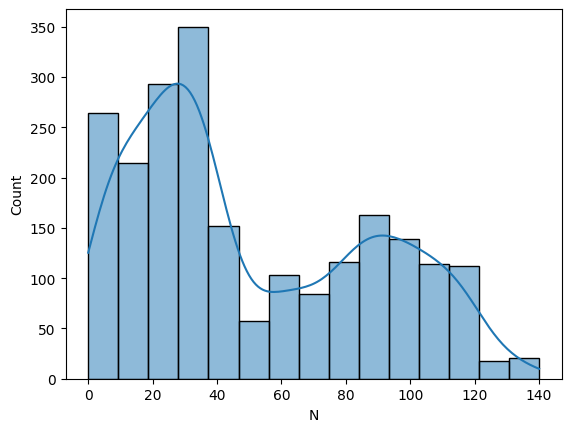

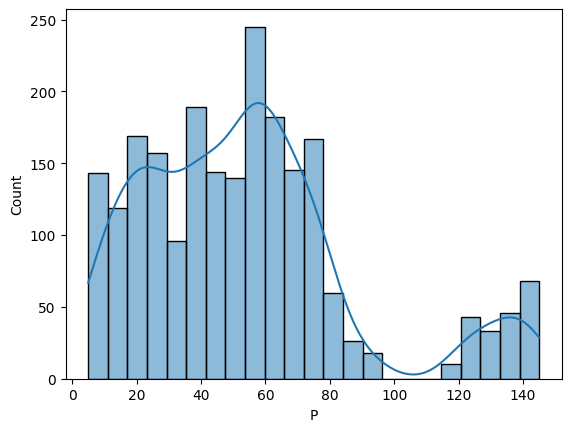

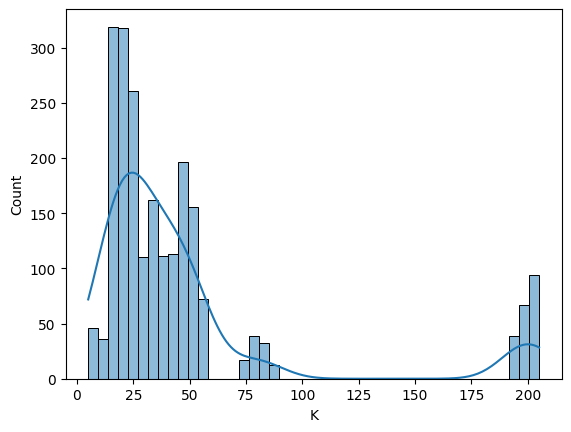

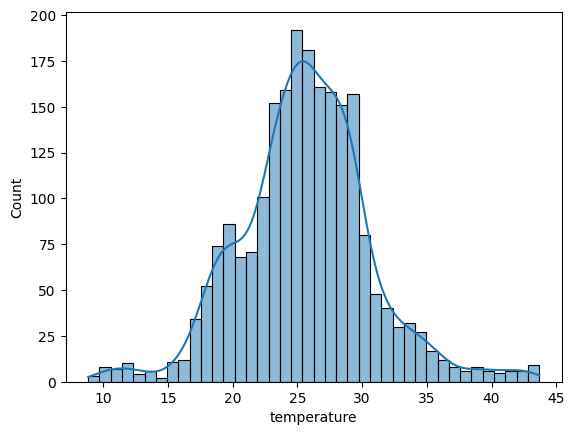

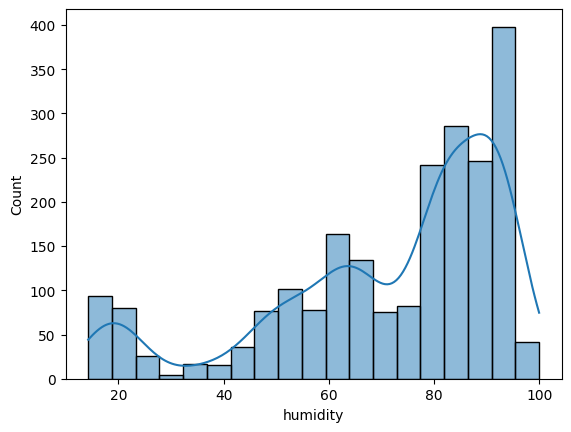

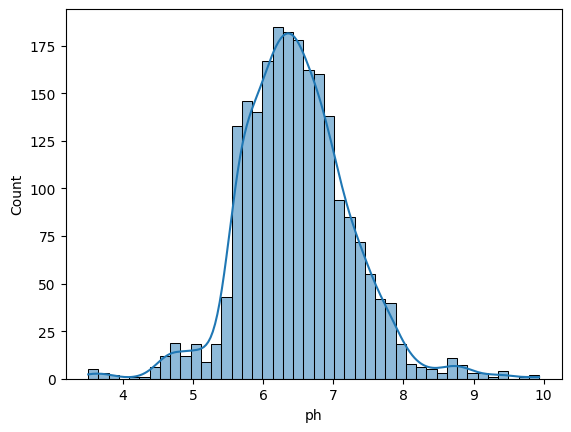

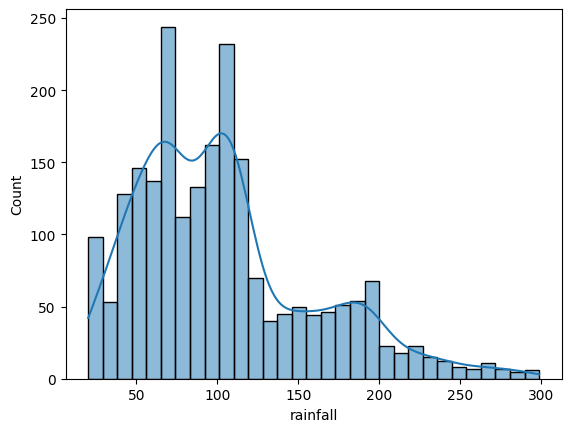

In [10]:
col=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for i in col:
    plt.Figure()
    sns.histplot(df[i],kde=True)
    plt.show()

In [11]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}

df['crop_num'] = df['label'].map(crop_dict)

print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label  crop_num
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice         1
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice         1
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice         1
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice         1
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice         1


In [12]:
corr=df.drop("label",axis=1).corr()
corr

,N,P,K,temperature,humidity,ph,rainfall,crop_num
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020,-0.317076
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839,0.109993
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461,-0.089209
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084,-0.031383
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423,-0.640925
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069,0.057527
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000,-0.311053
crop_num,-0.317076,0.109993,-0.089209,-0.031383,-0.640925,0.057527,-0.311053,1.000000


<Axes: >

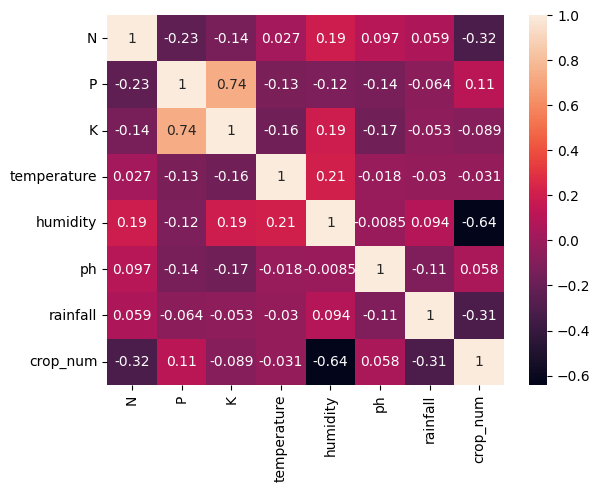

In [13]:
sns.heatmap(corr,annot=True)

In [14]:
scaler=MinMaxScaler()

In [15]:
col=["N","P","K","temperature","humidity","ph","rainfall"]
df[col]=scaler.fit_transform(df[col])

In [16]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,crop_num
0,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,0.656458,rice,1
1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,0.741675,rice,1
2,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,0.875710,rice,1
3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,0.799905,rice,1
4,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,0.871231,rice,1


In [17]:
df_clean=df.copy()

In [18]:
df_clean.drop("label",axis=1,inplace=True)

In [19]:
df_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,0.656458,1
1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,0.741675,1
2,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,0.875710,1
3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,0.799905,1
4,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,0.871231,1


In [20]:
final_df=df_clean[["N","P","K","temperature","humidity","ph","rainfall","crop_num"]]

In [21]:
x=final_df.drop("crop_num",axis=1)
y=final_df["crop_num"]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [23]:
models = {

    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Naive Bayes': GaussianNB(),

    'K-Nearest Neighbors': KNeighborsClassifier(),

}

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
for name,model in models.items():
    model.fit(x_train,y_train)
    y_predict=model.predict(x_test)
    
#accuracy
    print(f"{name} model accuracy: {accuracy_score(y_test,y_predict)}")
#confusion metrix
    print("confusion metrix")
    print(confusion_matrix(y_test,y_predict))
#classification report
    print(classification_report(y_test,y_predict))

Logistic Regression model accuracy: 0.9181818181818182
confusion metrix
[[16  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 6  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 3  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0

In [25]:
model=GaussianNB()
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [26]:
y_predict=model.predict(x_test)

In [27]:
print(x.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='str')


In [28]:
print(x_train.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='str')


In [29]:
print(scaler.feature_names_in_)

['N' 'P' 'K' 'temperature' 'humidity' 'ph' 'rainfall']


In [30]:
# Reverse the crop_dict for decoding
crop_dict_reverse = {v: k for k, v in crop_dict.items()}

def recommendation(N, P, K, temperature, humidity, ph, rainfall):

    features = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    )

    # Scale input data
    transformed_features = scaler.transform(features)

    # Predict encoded label
    prediction = model.predict(transformed_features)

    # Convert encoded label to crop name using crop_dict_reverse
    crop_name = crop_dict_reverse[prediction[0]]

    return crop_name

In [31]:
# INPUT VALUES
# =========================
N = 102
P = 28
K = 54
temperature = 25.15623099
humidity = 80.27525115
ph = 6.862157042
rainfall = 55.49541453

# =========================
# PREDICTION
# =========================
predict = recommendation(
    N,
    P,
    K,
    temperature,
    humidity,
    ph,
    rainfall
)

print("Recommended Crop :", predict)

Recommended Crop : watermelon


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [32]:
predict = recommendation(90, 42, 43, 20.87, 82.00, 6.50, 202.93)
print("Recommended Crop :", predict)

Recommended Crop : rice


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [33]:
predict = recommendation(103, 18, 30, 26.77, 58.99, 6.75, 158.07)
print("Recommended Crop :", predict)

Recommended Crop : coffee


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [34]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))